# Data Loading & Balancing

In [4]:
!pip install "datasets>=2.18.0,<3.0.0" scikit-learn pandas numpy matplotlib seaborn -q

In [5]:
CATEGORIES = [
    "Electronics",
    "Books",
    "Clothing_Shoes_and_Jewelry",
    "Home_and_Kitchen",
    "Toys_and_Games",
]

CATEGORY_LABELS = {
    "Electronics":                "Electronics",
    "Books":                      "Books",
    "Clothing_Shoes_and_Jewelry": "Clothing",
    "Home_and_Kitchen":           "Home & Kitchen",
    "Toys_and_Games":             "Toys",
}

FILE_STEMS = {
    "Electronics":                "electronics",
    "Books":                      "books",
    "Clothing_Shoes_and_Jewelry": "clothing",
    "Home_and_Kitchen":           "home_kitchen",
    "Toys_and_Games":             "toys",
}

SAMPLES_PER_CLASS = 2500     # 2500 pos + 2500 neg = 5000/category = 25000 total
TRAIN_RATIO       = 0.70     # 3500 train
VAL_RATIO         = 0.15     #  750 val
TEST_RATIO        = 0.15     #  750 test
RANDOM_SEED       = 104
DRIVE_BASE        = "/content/drive/MyDrive/cross-category-sentiment-robustness"

In [6]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from google.colab import drive

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

drive.mount("/content/drive")
DATA_DIR = f"{DRIVE_BASE}/data"
os.makedirs(DATA_DIR, exist_ok=True)
print("Data directory:", DATA_DIR)

Mounted at /content/drive
Data directory: /content/drive/MyDrive/cross-category-sentiment-robustness/data


In [7]:
import re

def stream_and_sample(category: str, samples_per_class: int, seed: int) -> pd.DataFrame:
    dataset = load_dataset(
        "McAuley-Lab/Amazon-Reviews-2023",
        f"raw_review_{category}",
        split="full",
        streaming=True,
        trust_remote_code=True,
    )

    positives, negatives = [], []
    target = samples_per_class

    for item in dataset:
        if len(positives) >= target and len(negatives) >= target:
            break
        rating = item.get("rating", item.get("overall"))
        if rating is None:
            continue
        rating = float(rating)
        text = str(item.get("text", item.get("reviewText", ""))).strip()
        text = re.sub(r"<[^>]+>", " ", text).strip()
        if not text:
            continue
        if rating >= 4.0 and len(positives) < target:
            positives.append({"text": text, "label": 1, "rating": rating})
        elif rating <= 2.0 and len(negatives) < target:
            negatives.append({"text": text, "label": 0, "rating": rating})

    df = pd.DataFrame(positives + negatives)
    df = df.sample(frac=1, random_state=seed).reset_index(drop=True)
    print(f"  {category}: {len(positives)} positive, {len(negatives)} negative")
    return df

In [8]:
all_data: dict[str, pd.DataFrame] = {}

for cat in CATEGORIES:
    print(f"Streaming {cat} ...")
    df = stream_and_sample(cat, SAMPLES_PER_CLASS, RANDOM_SEED)
    all_data[cat] = df

print()
print("All categories loaded.")

Streaming Electronics ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


  Electronics: 2500 positive, 2500 negative
Streaming Books ...
  Books: 2500 positive, 2500 negative
Streaming Clothing_Shoes_and_Jewelry ...
  Clothing_Shoes_and_Jewelry: 2500 positive, 2500 negative
Streaming Home_and_Kitchen ...
  Home_and_Kitchen: 2500 positive, 2500 negative
Streaming Toys_and_Games ...
  Toys_and_Games: 2500 positive, 2500 negative

All categories loaded.


In [9]:
splits: dict[str, dict[str, pd.DataFrame]] = {}

for cat, df in all_data.items():
    stem = FILE_STEMS[cat]

    # Step 1: hold out test set
    trainval_df, test_df = train_test_split(
        df, test_size=TEST_RATIO, random_state=RANDOM_SEED, stratify=df["label"]
    )
    # Step 2: split remaining into train and val
    val_ratio_of_trainval = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
    train_df, val_df = train_test_split(
        trainval_df, test_size=val_ratio_of_trainval,
        random_state=RANDOM_SEED, stratify=trainval_df["label"]
    )

    splits[cat] = {
        "train": train_df.reset_index(drop=True),
        "val":   val_df.reset_index(drop=True),
        "test":  test_df.reset_index(drop=True),
    }

    train_df.to_csv(f"{DATA_DIR}/{stem}_train.csv", index=False)
    val_df.to_csv(f"{DATA_DIR}/{stem}_val.csv",   index=False)
    test_df.to_csv(f"{DATA_DIR}/{stem}_test.csv",  index=False)
    print(f"{cat}: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")

Electronics: train=3500, val=750, test=750
Books: train=3500, val=750, test=750
Clothing_Shoes_and_Jewelry: train=3500, val=750, test=750
Home_and_Kitchen: train=3500, val=750, test=750
Toys_and_Games: train=3500, val=750, test=750


## Visualisation 1: Class distribution per category

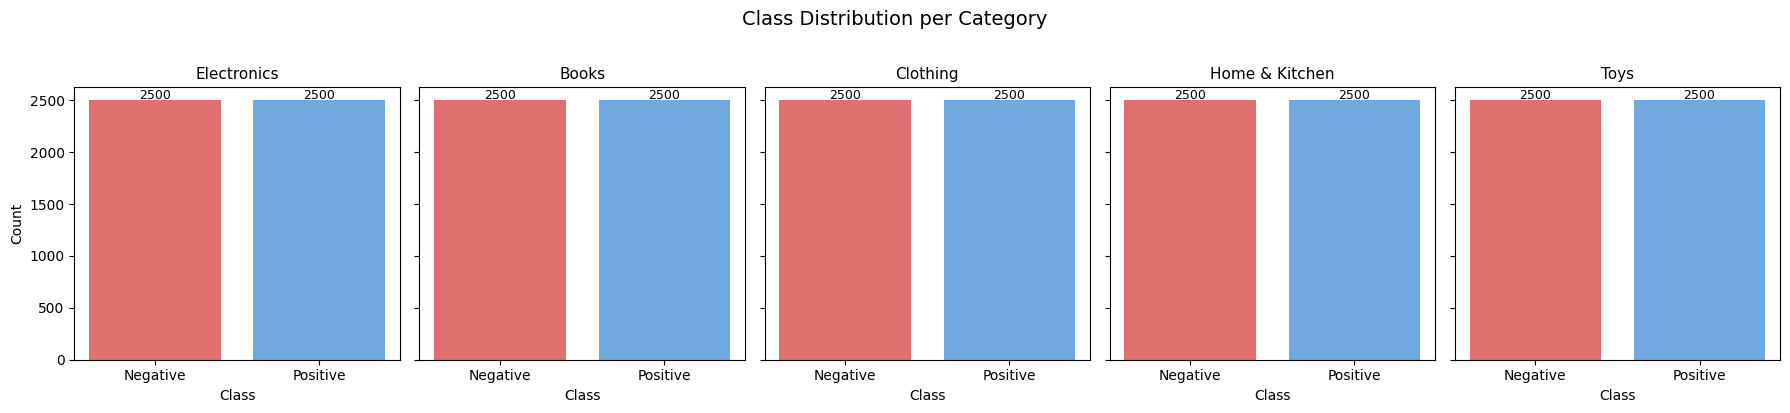

In [10]:
fig, axes = plt.subplots(1, len(CATEGORIES), figsize=(18, 4), sharey=True)

for ax, cat in zip(axes, CATEGORIES):
    counts = all_data[cat]["label"].value_counts().sort_index()
    ax.bar(["Negative", "Positive"], counts.values, color=["#e07070", "#70a8e0"])
    ax.set_title(CATEGORY_LABELS[cat], fontsize=11)
    ax.set_xlabel("Class")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 10, str(v), ha="center", fontsize=9)

axes[0].set_ylabel("Count")
fig.suptitle("Class Distribution per Category", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Visualisation 2: Review length distribution

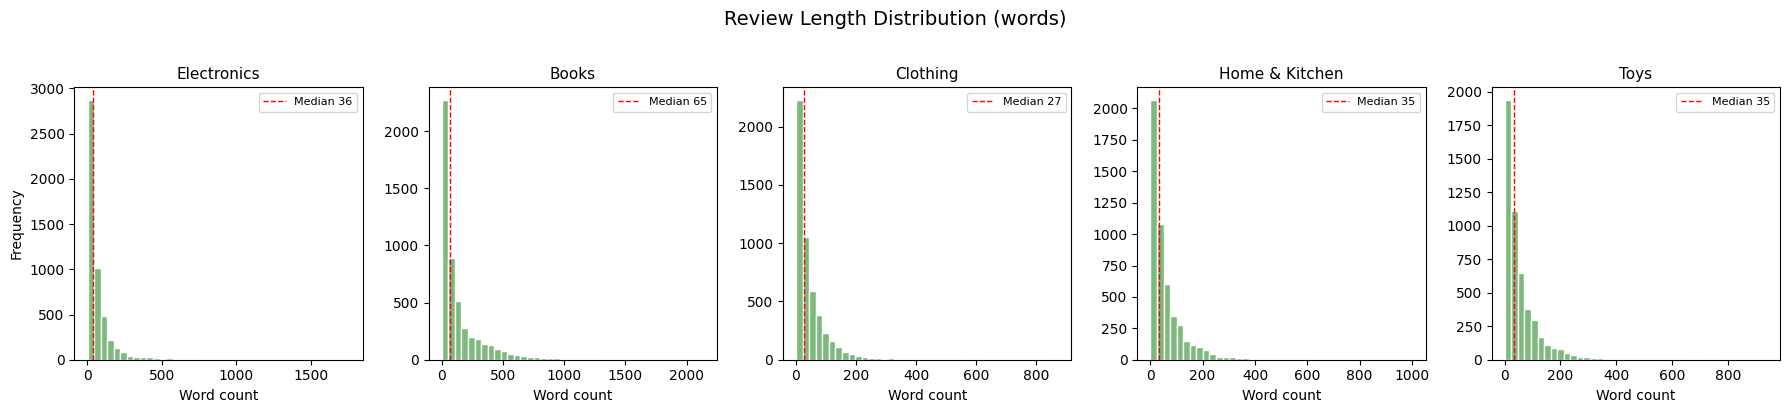

In [11]:
fig, axes = plt.subplots(1, len(CATEGORIES), figsize=(18, 4), sharey=False)

for ax, cat in zip(axes, CATEGORIES):
    lengths = all_data[cat]["text"].str.split().str.len()
    ax.hist(lengths, bins=40, color="#7db87d", edgecolor="white")
    ax.set_title(CATEGORY_LABELS[cat], fontsize=11)
    ax.set_xlabel("Word count")
    ax.axvline(lengths.median(), color="red", linestyle="--", linewidth=1,
               label=f"Median {lengths.median():.0f}")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Frequency")
fig.suptitle("Review Length Distribution (words)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Visualisation 3: Sample reviews (5 positive + 5 negative per category)

In [12]:
for cat in CATEGORIES:
    df = all_data[cat]
    pos = df[df["label"] == 1].sample(5, random_state=RANDOM_SEED)
    neg = df[df["label"] == 0].sample(5, random_state=RANDOM_SEED)
    sample = pd.concat([pos, neg])[["label", "text"]].copy()
    sample["text"] = sample["text"].str[:120] + "..."
    sample["sentiment"] = sample["label"].map({1: "positive", 0: "negative"})
    sample = sample[["sentiment", "text"]].reset_index(drop=True)

    print()
    print(f"Category: {CATEGORY_LABELS[cat]}")
    print(sample.to_string(index=False))


Category: Electronics
sentiment                                                                                                                      text
 positive                                                                                                   adjustable and elastic...
 positive                                                                                                 I used this for my iPod....
 positive                                                                                                             Worked great...
 positive Husband drives a lot and needed a reliable, easy to use hands free headset.  The only issue is that you MUST remember  t...
 positive I bought this thinking it was me, but I'm pretty sure it was refurbished even though it wasn't stated on the page. One o...
 negative I spent 12+ hours over several days on setup, testing, and investigation and cannot recommend this camera in its current...
 negative had in wallet and have lost 2 c

## Summary statistics

In [13]:
rows = []
for cat in CATEGORIES:
    df = all_data[cat]
    rows.append({
        "Category":     CATEGORY_LABELS[cat],
        "Total":        len(df),
        "Positive":     (df["label"] == 1).sum(),
        "Negative":     (df["label"] == 0).sum(),
        "Train":        len(splits[cat]["train"]),
        "Val":          len(splits[cat]["val"]),
        "Test":         len(splits[cat]["test"]),
        "Median words": int(df["text"].str.split().str.len().median()),
    })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

      Category  Total  Positive  Negative  Train  Val  Test  Median words
   Electronics   5000      2500      2500   3500  750   750            36
         Books   5000      2500      2500   3500  750   750            65
      Clothing   5000      2500      2500   3500  750   750            27
Home & Kitchen   5000      2500      2500   3500  750   750            35
          Toys   5000      2500      2500   3500  750   750            35
